In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Sin function

In [2]:
np.sin(np.pi/2)

1.0

Now we are giong to generate 2000 points from sin function wit equal range in [0,10].

In [3]:
time = np.linspace(0 , 10*np.pi , 2000)

In [4]:
data = np.sin(time)

Generated data.

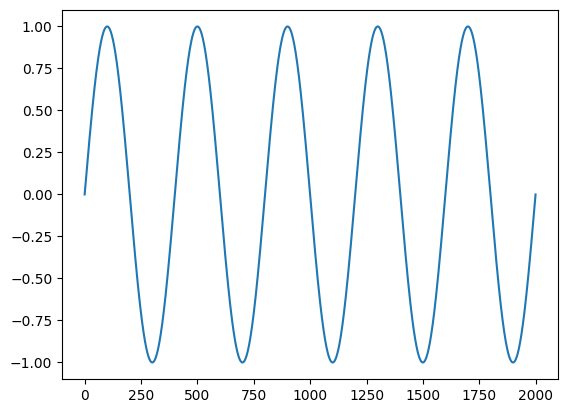

In [5]:
plt.plot(data)
plt.show()

For more claerfull plotting 30 points with scatter function.

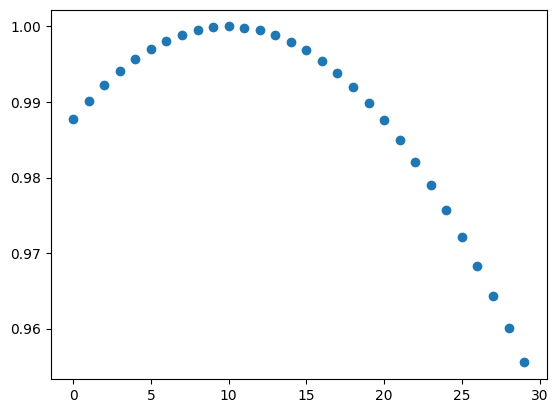

In [6]:
plt.scatter(np.arange(30) , data[90:120])

Prepairing data.

Its like some Regression issue. Then we have to prepair our dataset for RNN like regression issue.

First we have to set our sequence size and then the next oint will be our label.
Immagine our seq size = 20 , then label = 21th point.

In [7]:
seq = 20 
X = []
y = []

for i in range(len(data) - seq):
    X.append(data[i:i+seq])
    y.append(data[i+seq])

X = np.array(X)
y = np.array(y)


In [8]:
X.shape

(1980, 20)

X shape is showing that we have 1980 sequences and each one has 20 points.

But RNN want's one mor dimantion and it's the features of every point. We are goona solve this issue to with a simple reshape trick.

In [9]:
X = X.reshape(*X.shape,1)

In [10]:
X.shape

(1980, 20, 1)

Train and Test data separation.

In [11]:
X_train , X_test = X[:1584] , X[1584:]
y_train , y_test = y[:1584] , y[1584:]

In [12]:
import tensorflow as tf
from tensorflow.keras.layers import Dense,SimpleRNN
from tensorflow.keras.models import Sequential

In [13]:
model = Sequential()
model.add(SimpleRNN(units=32 , input_shape = (20,1) , activation='tanh'))
model.add(Dense(1,activation='linear'))

d:\python-venv\keras2\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [14]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 32)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,121 (4.38 KB)

 Trainable params: 1,121 (4.38 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
model.compile(loss='mean_absolute_error' , optimizer='adam')

In [16]:
model.fit(X_train,y_train,epochs=10,batch_size=25,validation_split=0.2,verbose=2)

Epoch 1/10
51/51 - 1s - 19ms/step - loss: 0.0513 - val_loss: 0.0180
Epoch 2/10
51/51 - 0s - 3ms/step - loss: 0.0092 - val_loss: 0.0074
Epoch 3/10
51/51 - 0s - 3ms/step - loss: 0.0062 - val_loss: 0.0064
Epoch 4/10
51/51 - 0s - 3ms/step - loss: 0.0110 - val_loss: 0.0117
Epoch 5/10
51/51 - 0s - 3ms/step - loss: 0.0060 - val_loss: 0.0040
Epoch 6/10
51/51 - 0s - 3ms/step - loss: 0.0089 - val_loss: 0.0062
Epoch 7/10
51/51 - 0s - 3ms/step - loss: 0.0064 - val_loss: 0.0204
Epoch 8/10
51/51 - 0s - 3ms/step - loss: 0.0107 - val_loss: 0.0020
Epoch 9/10
51/51 - 0s - 3ms/step - loss: 0.0079 - val_loss: 0.0055
Epoch 10/10
51/51 - 0s - 3ms/step - loss: 0.0068 - val_loss: 0.0072


In [17]:
model.evaluate(X_test,y_test)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0071 


0.007128209341317415

In [18]:
pred = model.predict(X_test)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


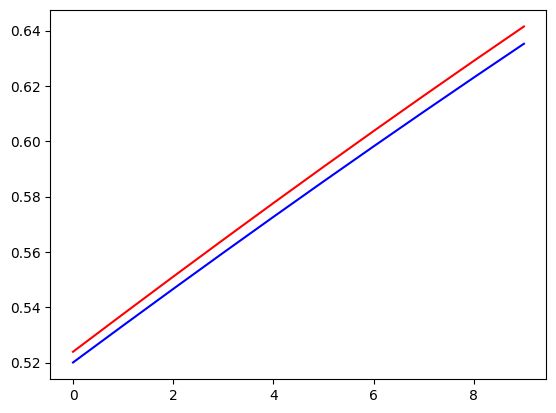

In [19]:
plt.plot(pred[30:40] , color='red')
plt.plot(y_test[30:40] , color='blue')
plt.show()

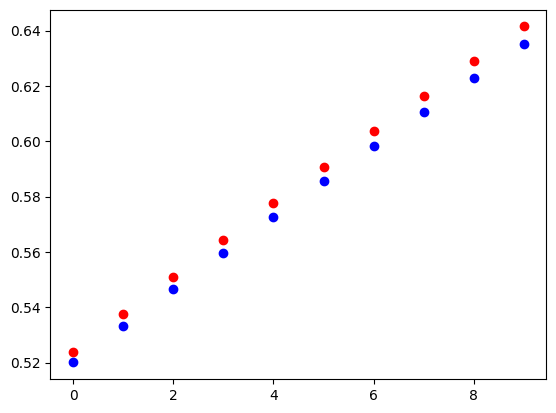

In [20]:
plt.scatter(np.arange(0,10) , pred[30:40] , color='red')
plt.scatter(np.arange(0,10) , y_test[30:40] , color='blue')
plt.show()